# Data Collection
### Target Asset

- **XAU/USD** via `yfinance` (daily OHLCV)
- Convert to IDR: multiply by **USD/IDR** (`IDR=X` on yfinance)

### Feature Data Sources
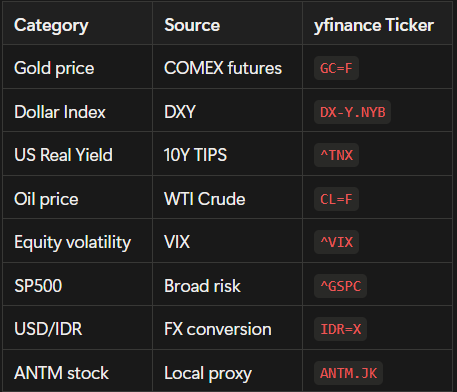

In [14]:
import yfinance as yf
import pandas as pd

df = yf.download("GC=F", start="2010-01-01")
df.columns = [f"gold_{col.lower()}" for col in df.columns.droplevel(1)]
df

[*********************100%***********************]  1 of 1 completed


,gold_close,gold_high,gold_low,gold_open,gold_volume
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54
...,...,...,...,...,...
2026-06-01,4475.200195,4541.399902,4449.700195,4523.500000,835
2026-06-02,4489.100098,4529.500000,4474.200195,4488.000000,456
2026-06-03,4436.700195,4471.700195,4427.200195,4471.200195,2913
2026-06-04,4475.799805,4509.899902,4447.399902,4447.399902,480


In [15]:
tickers = ["DX-Y.NYB", "^TNX", "CL=F", "^VIX", "^GSPC", "IDR=X", "ANTM.JK"]
df_helper = yf.download(tickers, start="2010-01-01")["Close"]
ticker_rename = {
    "DX-Y.NYB": "dxy_close",
    "^TNX":     "tnx_close",
    "CL=F":     "oil_close",
    "^VIX":     "vix_close",
    "^GSPC":    "sp500_close",
    "IDR=X":    "usdidr_close",
    "ANTM.JK":  "antm_close"
}
df_helper = df_helper.rename(columns=ticker_rename)

# Merge the gold data with the helper data
df = df.join(df_helper, how="inner")

# Drop rows where gold close is missing (non-trading days)
df = df.dropna(subset=["gold_close"])

# Forward-fill macro features for minor gaps (e.g. IDX holidays)
macro_cols = ["dxy_close", "tnx_close", "oil_close", 
              "vix_close", "sp500_close", "usdidr_close", "antm_close"]
df[macro_cols] = df[macro_cols].ffill()

[*********************100%***********************]  7 of 7 completed


In [16]:
df

,gold_close,gold_high,gold_low,gold_open,gold_volume,antm_close,oil_close,dxy_close,usdidr_close,sp500_close,tnx_close,vix_close
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,1403.310181,81.510002,77.529999,9364.200195,1132.989990,3.841,20.040001
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,1403.310181,81.769997,77.620003,9305.200195,1136.520020,3.755,19.350000
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,1403.310181,83.180000,77.489998,9218.099609,1137.140015,3.808,19.160000
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,1433.817139,82.660004,77.910004,9272.500000,1141.689941,3.822,19.059999
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,1433.817139,82.750000,77.470001,9212.700195,1144.979980,3.808,18.129999
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,4475.200195,4541.399902,4449.700195,4523.500000,835,2900.000000,92.160004,99.199997,17817.000000,7599.959961,4.475,16.049999
2026-06-02,4489.100098,4529.500000,4474.200195,4488.000000,456,2960.000000,93.760002,99.220001,17864.000000,7609.779785,4.455,15.770000
2026-06-03,4436.700195,4471.700195,4427.200195,4471.200195,2913,2610.000000,96.019997,99.529999,17858.000000,7553.680176,4.491,16.059999
2026-06-04,4475.799805,4509.899902,4447.399902,4447.399902,480,2760.000000,93.040001,99.410004,18004.199219,7584.310059,4.477,15.400000


# Feature Engineering

## Technical Features

In [17]:
import ta
import numpy as np

# ── Gold OHLC features ──────────────────────────────────────────
# Price-based indicators (use Close)
df["rsi_14"]    = ta.momentum.RSIIndicator(df["gold_close"], 14).rsi()
df["macd"]      = ta.trend.MACD(df["gold_close"]).macd_diff()
df["bb_pct"]    = ta.volatility.BollingerBands(df["gold_close"]).bollinger_pband()
df["ema_21"]    = df["gold_close"].ewm(span=21).mean()
df["ema_50"]    = df["gold_close"].ewm(span=50).mean()
df["ema_cross"] = df["ema_21"] - df["ema_50"]

# OHLC-derived features (gold only)
df["atr_14"]        = ta.volatility.AverageTrueRange(
                          df["gold_high"], df["gold_low"], df["gold_close"], window=14
                      ).average_true_range()
df["atr_pct"]       = df["atr_14"] / df["gold_close"]
df["daily_range"]   = (df["gold_high"] - df["gold_low"]) / df["gold_close"]
df["close_position"]= (df["gold_close"] - df["gold_low"]) / \
                      (df["gold_high"] - df["gold_low"])  # 0=weak, 1=strong
df["body_pct"]      = (df["gold_close"] - df["gold_open"]) / df["gold_close"]
df["upper_wick"]    = (df["gold_high"] - df[["gold_open","gold_close"]].max(axis=1)) \
                      / df["gold_close"]
df["lower_wick"]    = (df[["gold_open","gold_close"]].min(axis=1) - df["gold_low"]) \
                      / df["gold_close"]
df["overnight_gap"] = (df["gold_open"] - df["gold_close"].shift(1)) / \
                       df["gold_close"].shift(1)

# Garman-Klass volatility
df["gk_vol"] = np.sqrt(
    0.5 * np.log(df["gold_high"] / df["gold_low"])**2 -
    (2 * np.log(2) - 1) * np.log(df["gold_close"] / df["gold_open"])**2
)

# ── Macro features (Close only) ─────────────────────────────────
df["dxy_return"]    = df["dxy_close"].pct_change(5)
df["vix_level"]     = df["vix_close"]
df["vix_change"]    = df["vix_close"].pct_change(5)
df["yield_change"]  = df["tnx_close"].diff(5)
df["oil_return"]    = df["oil_close"].pct_change(5)
df["usdidr_return"] = df["usdidr_close"].pct_change(5)
df["antm_return"]   = df["antm_close"].pct_change(5)

c:\Users\ASUS\anaconda3\envs\stock_trading\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
df

,gold_close,gold_high,gold_low,gold_open,gold_volume,antm_close,oil_close,dxy_close,usdidr_close,sp500_close,...,lower_wick,overnight_gap,gk_vol,dxy_return,vix_level,vix_change,yield_change,oil_return,usdidr_return,antm_return
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,1403.310181,81.510002,77.529999,9364.200195,1132.989990,...,0.018431,NaN,0.016058,NaN,20.040001,NaN,NaN,NaN,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,1403.310181,81.769997,77.620003,9305.200195,1136.520020,...,0.002773,0.000358,0.007256,NaN,19.350000,NaN,NaN,NaN,NaN,NaN
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,1403.310181,83.180000,77.489998,9218.099609,1137.140015,...,0.013382,0.015920,0.011577,NaN,19.160000,NaN,NaN,NaN,NaN,NaN
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,1433.817139,82.660004,77.910004,9272.500000,1141.689941,...,0.003442,-0.002465,0.002438,NaN,19.059999,NaN,NaN,NaN,NaN,NaN
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,1433.817139,82.750000,77.470001,9212.700195,1144.979980,...,0.013618,0.004501,0.009696,NaN,18.129999,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,4475.200195,4541.399902,4449.700195,4523.500000,835,2900.000000,92.160004,99.199997,17817.000000,7599.959961,...,0.005698,-0.008113,0.012788,-0.001208,16.049999,-0.038922,-0.083,-0.045963,0.007065,-0.061489
2026-06-02,4489.100098,4529.500000,4474.200195,4488.000000,456,2960.000000,93.760002,99.220001,17864.000000,7609.779785,...,0.003074,0.002860,0.008685,0.000504,15.770000,-0.072898,-0.038,-0.001385,0.005743,0.000000
2026-06-03,4436.700195,4471.700195,4427.200195,4471.200195,2913,2610.000000,96.019997,99.529999,17858.000000,7553.680176,...,0.002141,-0.003987,0.005180,0.003225,16.059999,-0.014119,0.010,0.082769,0.008944,-0.118243
2026-06-04,4475.799805,4509.899902,4447.399902,4447.399902,480,2760.000000,93.040001,99.410004,18004.199219,7584.310059,...,0.000000,0.002412,0.009040,0.003939,15.400000,-0.021601,0.022,0.046569,0.011245,-0.067568


## Regime Features

In [19]:
import numpy as np

def hurst_exponent(ts, lags=range(2, 20)):
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]  # H > 0.5 trending, H < 0.5 mean-reverting

df["hurst_60d"] = df["gold_close"].rolling(60).apply(
    lambda x: hurst_exponent(x), raw=True
)
df["regime"] = (df["hurst_60d"] > 0.55).astype(int)  # 1=trending, 0=ranging

## Target Variable — Accumulation-Timing Meta-Labeling

The decision this model supports is **"is now a good time to add to a long-term gold position?"** —
not when to flip in and out daily. So we adapt Lopez de Prado's meta-labeling structure to a long
horizon:

1. **Primary signal (rule-based dip detector)**:
   `side = 1` when `gold_close` is more than 5% below its 200-day MA, else `side = 0`.
   This is the "buy the dip" candidate event stream.
2. **Realized return**: instead of triple-barrier, we use a fixed **12-month forward return**
   (≈ 252 trading bars) — appropriate for an accumulation horizon and avoids the noise of
   short-window barriers.
3. **Meta-label**: `target = 1` if `fwd_12m_ret > 4%` (rough USD cash hurdle), else `0`.
   The meta-model learns *which dips actually beat cash over the next year*.

Notes for this framing:
- `usdidr_return` dropped from features — it's a translation layer, not a driver of gold.
- Short-window technicals (RSI-14, MACD diff, candle wicks, gap) dropped — noise at this horizon.
- Long-horizon valuation features added: `dist_from_ma200`, `drawdown_from_peak`, `momentum_252d`.
- No "sell" model. Backtest compares model-picked dips against (a) buying every dip and
  (b) uniform DCA over the same window.


In [20]:
df = df.copy()

# ── Long-horizon valuation features ───────────────────────────────
df["ma_200"]             = df["gold_close"].rolling(200).mean()
df["dist_from_ma200"]    = df["gold_close"] / df["ma_200"] - 1          # < 0 = below long-term trend
df["drawdown_from_peak"] = df["gold_close"] / df["gold_close"].rolling(252).max() - 1
df["momentum_252d"]      = df["gold_close"].pct_change(252)
df["daily_vol"]          = df["gold_close"].pct_change().ewm(span=100).std()

# ── Primary signal: rule-based dip detector ───────────────────────
# Fires when price is at least `dip_threshold` below its 200-day MA.
dip_threshold = -0.05
df["side"] = (df["dist_from_ma200"] < dip_threshold).astype(int)        # 1 = candidate buy, 0 = ignore

# ── Forward 12-month return + cash-hurdle target ──────────────────
horizon_bars = 252
cash_hurdle  = 0.04                                                      # ≈ 4% USD over 12 months
df["fwd_12m_ret"] = df["gold_close"].shift(-horizon_bars) / df["gold_close"] - 1

# Snapshot of all bars with a valid forward return — used in the backtest
# to benchmark model picks against a passive DCA-over-all-bars baseline.
df_full = df.dropna(subset=["fwd_12m_ret"]).copy()

# ── Meta-label: 1 if buying this dip beats the cash hurdle over 12mo ──
events = df[df["side"] == 1].dropna(subset=["fwd_12m_ret"]).copy()
events["target"] = (events["fwd_12m_ret"] > cash_hurdle).astype(int)

# Restrict df to the event subset (train/val/test will see only these).
df = events
df["target"] = df["target"].astype(int)

print(f"Dip events       : {len(df)}")
print(f"Avg fwd-12mo ret : {df['fwd_12m_ret'].mean()*100:+.2f}%")
print(f"Hit rate (y=1)   : {df['target'].mean():.1%}")
print(df["target"].value_counts())


Dip events       : 600
Avg fwd-12mo ret : +4.61%
Hit rate (y=1)   : 52.8%
target
1    317
0    283
Name: count, dtype: int64


In [21]:
df

,gold_close,gold_high,gold_low,gold_open,gold_volume,antm_close,oil_close,dxy_close,usdidr_close,sp500_close,...,hurst_60d,regime,ma_200,dist_from_ma200,drawdown_from_peak,momentum_252d,daily_vol,side,fwd_12m_ret,target
2011-12-29,1539.900024,1559.300049,1525.000000,1559.300049,866,1997.270996,99.650002,80.480003,9044.400391,1263.020020,...,0.463431,0,1621.136003,-0.050111,-0.184677,0.095546,0.015677,1,0.096110,1
2012-05-08,1604.000000,1636.699951,1596.000000,1636.699951,154,1997.270996,97.010002,79.730003,9170.000000,1363.719971,...,0.178642,0,1697.369003,-0.055008,-0.150739,0.067270,0.011853,1,-0.104239,0
2012-05-09,1593.699951,1595.300049,1586.300049,1595.300049,30,1997.270996,96.809998,80.080002,9166.000000,1354.579956,...,0.171868,0,1697.277503,-0.061026,-0.156192,0.050837,0.011762,1,-0.099893,0
2012-05-10,1595.099976,1595.099976,1592.400024,1594.199951,6,1997.270996,97.080002,80.110001,9213.000000,1357.989990,...,0.175705,0,1697.170003,-0.060141,-0.155451,0.062621,0.011648,1,-0.106827,0
2012-05-11,1583.599976,1589.599976,1583.599976,1586.099976,6,1997.270996,96.129997,80.279999,9170.000000,1353.390015,...,0.183072,0,1697.013003,-0.066831,-0.161540,0.051108,0.011566,1,-0.118149,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-08,1712.099976,1712.099976,1703.199951,1703.199951,23,1675.529419,88.910004,109.620003,15675.000000,3828.110107,...,0.194274,0,1802.663998,-0.050239,-0.160776,-0.063095,0.010029,1,0.147246,1
2022-11-09,1710.099976,1720.199951,1706.000000,1707.400024,497,1688.190796,85.830002,110.550003,15645.000000,3748.570068,...,0.208636,0,1801.950999,-0.050973,-0.161757,-0.065621,0.009930,1,0.130109,1
2023-10-03,1824.599976,1830.900024,1816.800049,1825.000000,310,1551.182373,89.230003,107.000000,15516.000000,4229.450195,...,0.326320,0,1923.547998,-0.051440,-0.109082,0.097570,0.006857,1,0.456264,1
2023-10-04,1818.500000,1828.199951,1816.400024,1821.800049,357,1529.210938,84.220001,106.800003,15622.000000,4263.750000,...,0.356442,0,1923.754498,-0.054713,-0.112061,0.074192,0.006797,1,0.454935,1


# Modeling

In [22]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

In [23]:
df.columns

Index(['gold_close', 'gold_high', 'gold_low', 'gold_open', 'gold_volume',
       'antm_close', 'oil_close', 'dxy_close', 'usdidr_close', 'sp500_close',
       'tnx_close', 'vix_close', 'rsi_14', 'macd', 'bb_pct', 'ema_21',
       'ema_50', 'ema_cross', 'atr_14', 'atr_pct', 'daily_range',
       'close_position', 'body_pct', 'upper_wick', 'lower_wick',
       'overnight_gap', 'gk_vol', 'dxy_return', 'vix_level', 'vix_change',
       'yield_change', 'oil_return', 'usdidr_return', 'antm_return',
       'hurst_60d', 'regime', 'ma_200', 'dist_from_ma200',
       'drawdown_from_peak', 'momentum_252d', 'daily_vol', 'side',
       'fwd_12m_ret', 'target'],
      dtype='object')

In [24]:
import lightgbm as lgb
from sklearn.metrics import classification_report

# Feature set tuned for a 12-month accumulation horizon:
#   - long-term valuation / trend dominate
#   - vol-regime kept as a smoother stress indicator
#   - macro kept (DXY, real-yield proxy via TNX, VIX, oil, ANTM)
#   - short-window technicals + usdidr_return dropped
#   - `side` dropped (constant = 1 within the event subset)
features = [
    # Long-term valuation / trend
    'dist_from_ma200', 'drawdown_from_peak', 'momentum_252d',
    'ema_cross', 'hurst_60d', 'regime',
    # Volatility regime
    'atr_pct', 'gk_vol', 'daily_vol', 'bb_pct',
    # Macro
    'dxy_return', 'vix_level', 'vix_change',
    'yield_change', 'oil_return', 'antm_return',
]

X_train, y_train = train[features], train["target"]
X_val,   y_val   = val[features],   val["target"]

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50)])

print(classification_report(y_val, model.predict(X_val)))


[LightGBM] [Info] Number of positive: 137, number of negative: 283
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2085
[LightGBM] [Info] Number of data points in the train set: 420, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

c:\Users\ASUS\anaconda3\envs\stock_trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\anaconda3\envs\stock_trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\anaconda3\envs\stock_trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

# Backtesting

In [25]:
def backtest_accumulation(events_df, df_full_bars, prob_threshold=0.5, hurdle=0.04):
    """Accumulation-timing backtest.

    Compares the meta-model's dip picks against two baselines:
      (1) Always-dip:  buy at every primary-signal event in the window.
      (2) Uniform DCA: buy on every bar in the window (no dip filter).

    "PnL" per buy = realized 12-month forward return at that bar.
    """
    df = events_df.copy()
    df["proba"] = model.predict_proba(df[features])[:, 1]
    df["buy"]   = (df["proba"] >= prob_threshold).astype(int)

    triggered = df[df["buy"] == 1]
    win_start, win_end = df.index.min(), df.index.max()
    dca = df_full_bars.loc[win_start:win_end]

    def stats(name, rets):
        if len(rets) == 0:
            print(f"  {name:18s} : (no buys)")
            return
        print(f"  {name:18s} : N={len(rets):>4d}  "
              f"avg fwd-12mo={rets.mean()*100:+6.2f}%  "
              f"hit={'%5.1f' % ((rets > hurdle).mean()*100)}%  "
              f"std={rets.std()*100:5.2f}%")

    print(f"Test window      : {win_start.date()} → {win_end.date()}")
    print(f"Probability cut  : {prob_threshold:.2f}    Hurdle: {hurdle*100:.1f}%")
    print()
    stats("Model-triggered", triggered["fwd_12m_ret"])
    stats("Always-dip",      df["fwd_12m_ret"])
    stats("Uniform DCA",     dca["fwd_12m_ret"])

    return df


In [ ]:
# Sweep the probability threshold to see selectivity vs. average return trade-off.
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
rows = []
for p in thresholds:
    df_bt = test.copy()
    df_bt["proba"] = model.predict_proba(df_bt[features])[:, 1]
    buy = df_bt["proba"] >= p
    rets = df_bt.loc[buy, "fwd_12m_ret"]
    rows.append({
        "prob_thr": p,
        "n_buys":   int(buy.sum()),
        "avg_ret":  f"{rets.mean()*100:+.2f}%"          if len(rets) else "n/a",
        "hit_rate": f"{(rets > 0.04).mean()*100:.1f}%"  if len(rets) else "n/a",
    })

print("Threshold sweep on test set:\n")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Reference baselines on test window:")
backtest_accumulation(test, df_full, prob_threshold=0.50)


Threshold sweep on test set:

 prob_thr  n_buys avg_ret hit_rate
     0.40      90 +14.99%   100.0%
     0.45      90 +14.99%   100.0%
     0.50      71 +14.38%   100.0%
     0.55       0     n/a      n/a
     0.60       0     n/a      n/a
     0.65       0     n/a      n/a

Reference baselines on test window:
Test window      : 2021-03-23 → 2023-10-05
Probability cut  : 0.50    Hurdle: 4.0%

  Model-triggered    : N=  71  avg fwd-12mo=+14.38%  hit=100.0%  std= 3.98%
  Always-dip         : N=  90  avg fwd-12mo=+14.99%  hit=100.0%  std= 6.80%
  Uniform DCA        : N= 640  avg fwd-12mo= +8.88%  hit= 65.2%  std=10.82%


,gold_close,gold_high,gold_low,gold_open,gold_volume,antm_close,oil_close,dxy_close,usdidr_close,sp500_close,...,ma_200,dist_from_ma200,drawdown_from_peak,momentum_252d,daily_vol,side,fwd_12m_ret,target,proba,buy
2021-03-23,1724.699951,1724.699951,1724.699951,1724.699951,6,1872.796021,57.759998,92.339996,14375.799805,3910.520020,...,1854.606498,-0.070045,-0.159298,0.100638,0.010924,1,0.113643,1,0.480158,0
2021-03-24,1732.900024,1732.900024,1727.500000,1727.500000,26,1790.293945,61.180000,92.529999,14505.500000,3889.139893,...,1854.779498,-0.065711,-0.155301,0.043790,0.010844,1,0.117549,1,0.480158,0
2021-03-25,1724.900024,1733.199951,1724.500000,1732.699951,15,1798.544312,58.560001,92.879997,14460.000000,3909.520020,...,1854.830498,-0.070050,-0.159201,0.056730,0.010750,1,0.137225,1,0.480158,0
2021-03-26,1732.199951,1732.199951,1721.300049,1721.300049,33,2004.798950,60.970001,92.769997,14456.400391,3974.540039,...,1854.924998,-0.066162,-0.155642,0.049755,0.010666,1,0.127930,1,0.480158,0
2021-03-29,1712.099976,1712.099976,1712.099976,1712.099976,135457,1864.545898,61.560001,92.940002,14411.000000,3971.090088,...,1854.825497,-0.076948,-0.165440,0.054314,0.010669,1,0.132878,1,0.480158,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-08,1712.099976,1712.099976,1703.199951,1703.199951,23,1675.529419,88.910004,109.620003,15675.000000,3828.110107,...,1802.663998,-0.050239,-0.160776,-0.063095,0.010029,1,0.147246,1,0.520943,1
2022-11-09,1710.099976,1720.199951,1706.000000,1707.400024,497,1688.190796,85.830002,110.550003,15645.000000,3748.570068,...,1801.950999,-0.050973,-0.161757,-0.065621,0.009930,1,0.130109,1,0.520943,1
2023-10-03,1824.599976,1830.900024,1816.800049,1825.000000,310,1551.182373,89.230003,107.000000,15516.000000,4229.450195,...,1923.547998,-0.051440,-0.109082,0.097570,0.006857,1,0.456264,1,0.475021,0
2023-10-04,1818.500000,1828.199951,1816.400024,1821.800049,357,1529.210938,84.220001,106.800003,15622.000000,4263.750000,...,1923.754498,-0.054713,-0.112061,0.074192,0.006797,1,0.454935,1,0.475021,0


: 